In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the dataset
data = pd.read_csv('MNIST_Subset.csv', header=None)

# Extract the pixel values from the DataFrame and reshape them
images = data.values
images = images.reshape(-1, 28, 28)

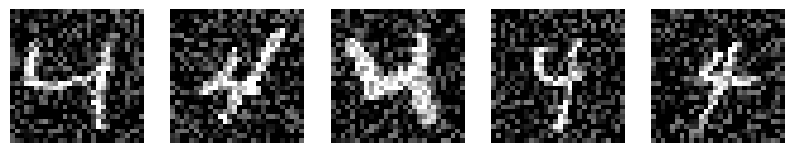

In [40]:
def plot_images(image_data, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(10, 5))
    for i in range(num_images):
        axes[i].imshow(image_data[i+1], cmap='gray')
        axes[i].axis('off')
    plt.show()

num_images_to_plot = 5  # Change this number to visualize more or fewer images
plot_images(images, num_images=num_images_to_plot)

In [41]:
num_images=5
U, S, Vt = np.linalg.svd(data)

In [42]:
def get_denoised_images(m):
    data_reconstructed = U[:,0:m].dot(np.diag(S[0:m])).dot(Vt[0:m,:])
    data_reconstructed = data_reconstructed.reshape(-1, 28, 28)
    return data_reconstructed[1:num_images+1]


def plot_noisy_vs_denoised(original_images, k, num=num_images):
    l = len(k)
    fig, axes = plt.subplots(num, l+1, figsize=(1.5*l, 6.5))
    for i in range(num):
        axes[i, 0].imshow(original_images[i], cmap='gray')
        axes[i, 0].set_title('Noisy')
        axes[i, 0].axis('off')

        for j in range(len(k)):
            denoised_images = get_denoised_images(m=k[j])
            axes[i, j+1].imshow(denoised_images[i], cmap='gray')
            axes[i, j+1].set_title(f'K={k[j]}')
            axes[i, j+1].axis('off')

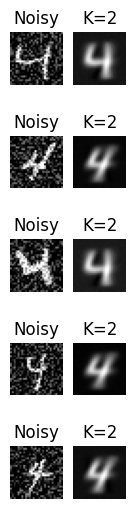

In [43]:
k = [2]
plot_noisy_vs_denoised(images[1:num_images+1], k)
plt.show()

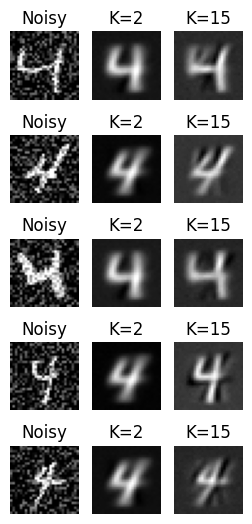

In [44]:
k = [2,15]
plot_noisy_vs_denoised(images[1:num_images+1], k)
plt.show()

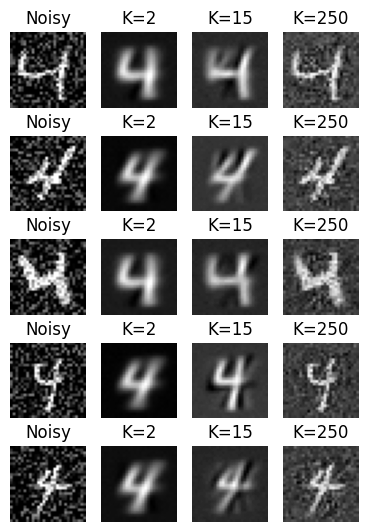

In [45]:
k = [2,15,250]
plot_noisy_vs_denoised(images[1:num_images+1], k)
plt.show()